In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [35]:
df = pd.read_csv('../../data/raw/data.csv')

In [36]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [37]:
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-10, 10)  

In [38]:
print("Shape:", df.shape)
df.info()

Shape: (4600, 18)
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes

In [39]:
df.head(2)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA


In [40]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,"4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16,"2,139.35","14,852.52",1.51,0.01,0.24,3.45,"1,827.27",312.08,"1,970.79",808.61
std,"563,834.70",0.91,0.78,963.21,"35,884.44",0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,"1,900.00",0.00
25%,"322,875.00",3.00,1.75,"1,460.00","5,000.75",1.00,0.00,0.00,3.00,"1,190.00",0.00,"1,951.00",0.00
50%,"460,943.46",3.00,2.25,"1,980.00","7,683.00",1.50,0.00,0.00,3.00,"1,590.00",0.00,"1,976.00",0.00
75%,"654,962.50",4.00,2.50,"2,620.00","11,001.25",2.00,0.00,0.00,4.00,"2,300.00",610.00,"1,997.00","1,999.00"
max,"26,590,000.00",9.00,8.00,"13,540.00","1,074,218.00",3.50,1.00,4.00,5.00,"9,410.00","4,820.00","2,014.00","2,014.00"


In [41]:
df.isnull().sum().sum()

np.int64(0)

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
# categorical_cols = ['date', 'street', 'city', 'statezip', 'country']
categorical_cols = ['street', 'city', 'statezip', 'country']
continuous_cols = ['price', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement']
discrete_cols = ['bedrooms', 'waterfront', 'view', 'condition', 'yr_built', 'yr_renovated']

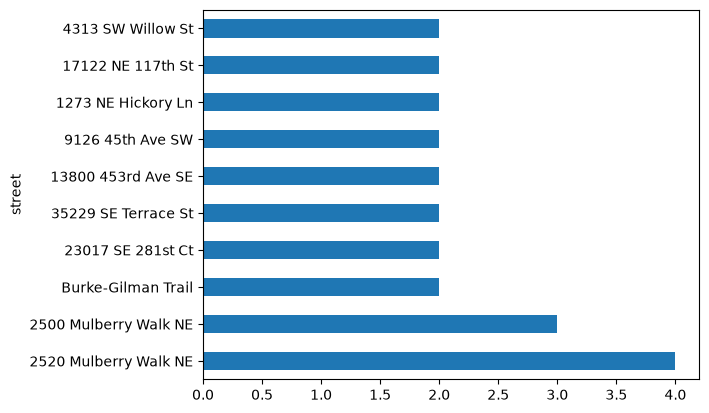

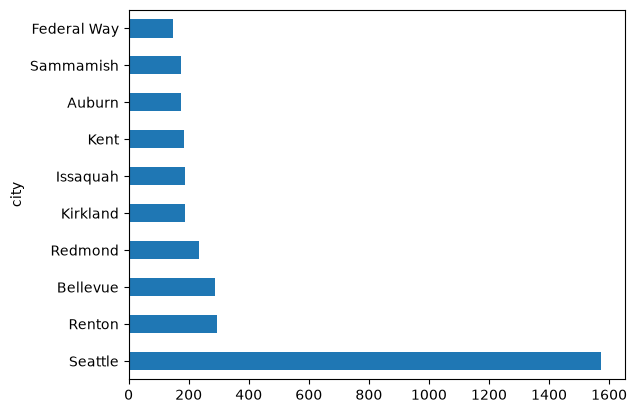

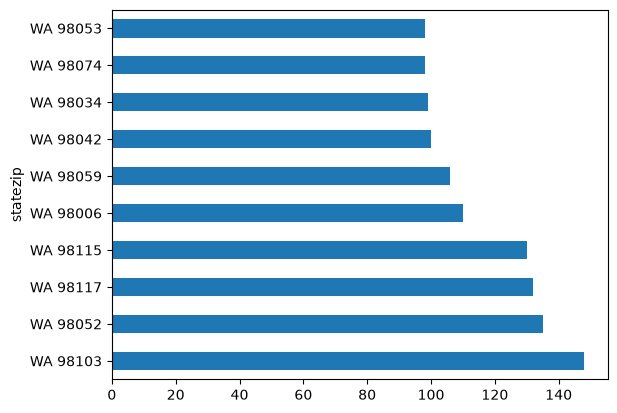

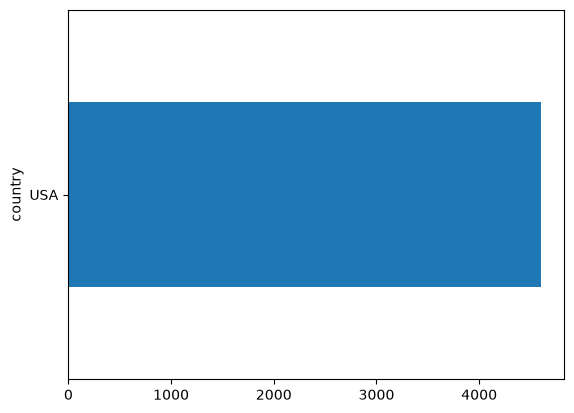

In [44]:
for col in categorical_cols:
    df[col].value_counts().head(10).plot(kind='barh')
    plt.show()

In [45]:
# - Seattle is the most common and prominent city in the dataset.
# - The 'country' column contains only one unique value.
# - There are no duplicate or missing values.

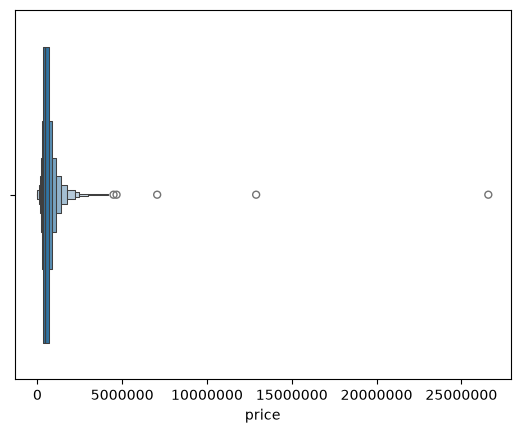

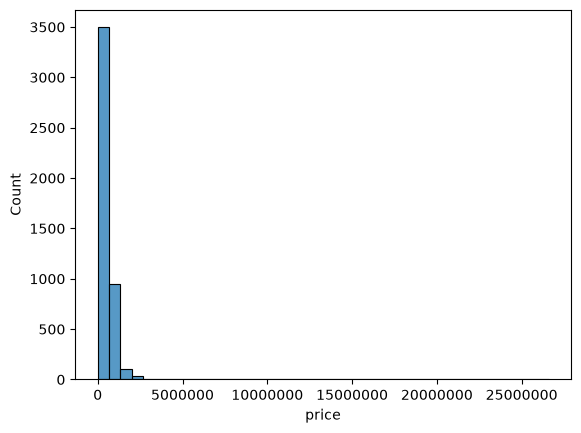

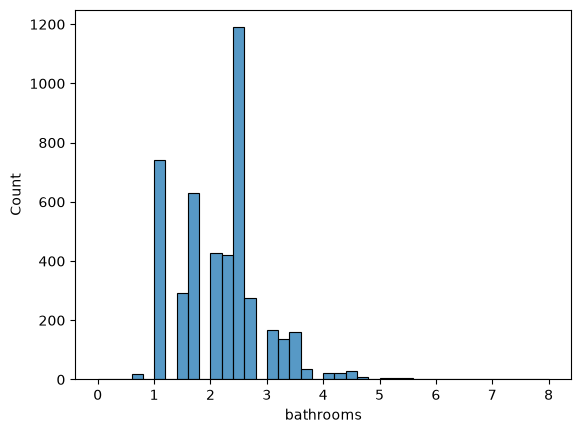

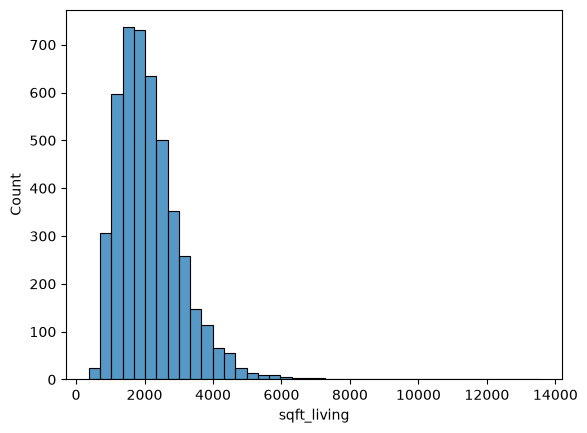

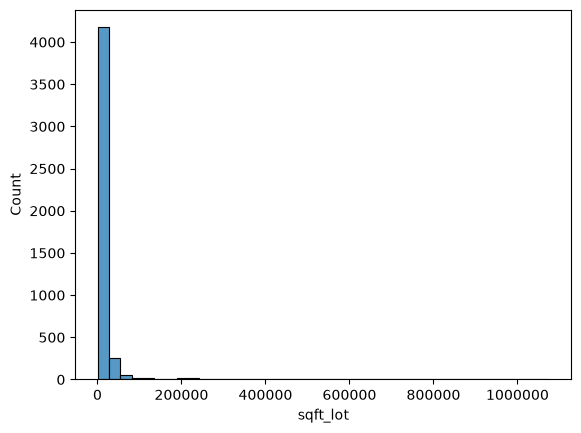

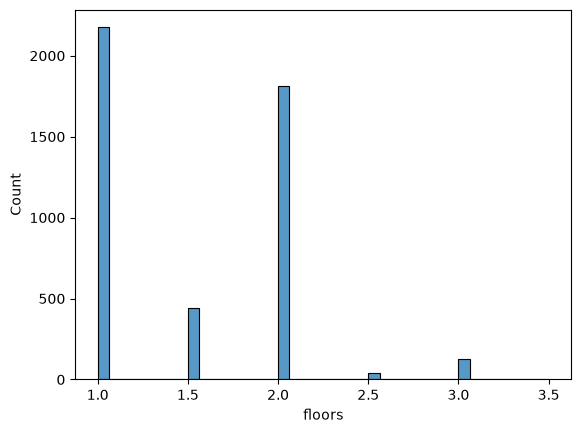

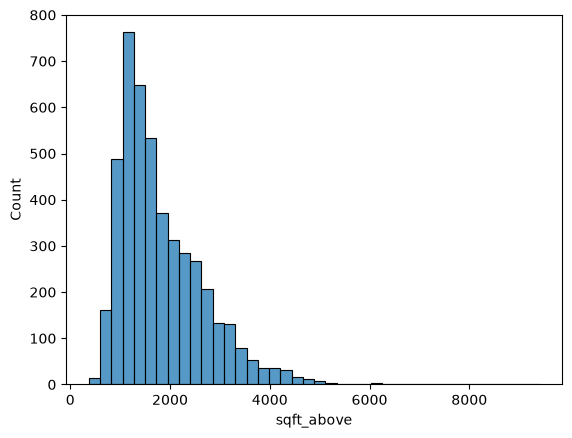

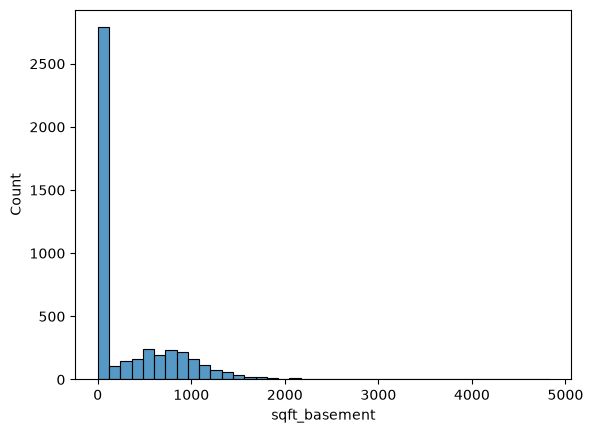

In [46]:
sns.boxenplot(data=df, x='price')
plt.show()
for col in continuous_cols:
    sns.histplot(data=df, x=col, bins=40)
    plt.show()

In [47]:
# - The 'price' column is right-skewed.
# - 'price', 'sqft_lot', 'sqft_living', and 'sqft_basement' contain numerous outliers.
# - Check for invalid values that are less than or equal to zero.
# 'sqft_living' has the strongest positive correlation with price.

In [48]:
df.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.00,0.20,0.33,0.43,0.05,0.15,0.14,0.23,0.03,0.37,0.21,0.02,-0.03
bedrooms,0.20,1.00,0.55,0.59,0.07,0.18,-0.00,0.11,0.03,0.48,0.33,0.14,-0.06
bathrooms,0.33,0.55,1.00,0.76,0.11,0.49,0.08,0.21,-0.12,0.69,0.30,0.46,-0.22
sqft_living,0.43,0.59,0.76,1.00,0.21,0.34,0.12,0.31,-0.06,0.88,0.45,0.29,-0.12
sqft_lot,0.05,0.07,0.11,0.21,1.00,0.00,0.02,0.07,0.00,0.22,0.03,0.05,-0.02
floors,0.15,0.18,0.49,0.34,0.00,1.00,0.02,0.03,-0.28,0.52,-0.26,0.47,-0.23
waterfront,0.14,-0.00,0.08,0.12,0.02,0.02,1.00,0.36,0.00,0.08,0.10,-0.02,0.01
view,0.23,0.11,0.21,0.31,0.07,0.03,0.36,1.00,0.06,0.17,0.32,-0.06,0.02
condition,0.03,0.03,-0.12,-0.06,0.00,-0.28,0.00,0.06,1.00,-0.18,0.20,-0.40,-0.19
sqft_above,0.37,0.48,0.69,0.88,0.22,0.52,0.08,0.17,-0.18,1.00,-0.04,0.41,-0.16


In [49]:
invalid_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
for col in invalid_cols:
    print(f"{col}: {len(df[df[col] <= 0])} rows with <= 0")


price: 49 rows with <= 0
bedrooms: 2 rows with <= 0
bathrooms: 2 rows with <= 0
sqft_living: 0 rows with <= 0
sqft_lot: 0 rows with <= 0
